# Lineup Modeling & Advanced Metrics

In this notebook, we extend the lineup analysis by refining performance metrics and introducing more stable, comparable measures of lineup effectiveness.

While previous notebooks focused on raw and time-normalized performance, here we aim to:

- Reduce noise from small sample sizes
- Improve comparability across lineups
- Identify consistently effective combinations
- Prepare features for future predictive modeling

This notebook represents the transition from exploratory analysis to structured performance modeling.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 200)

## Load processed datasets

We load the lineup and player-pair datasets created in previous notebooks.

These processed files allow this notebook to focus on modeling-oriented analysis rather than rebuilding earlier transformations.

In [16]:
lineup_perf = pd.read_csv("../data/processed/lineup_performance.csv")
reliable_lineups = pd.read_csv("../data/processed/reliable_lineups.csv")
pair_perf = pd.read_csv("../data/processed/pair_performance.csv")
reliable_pairs = pd.read_csv("../data/processed/reliable_pair_performance.csv")

print("Total lineups:", len(lineup_perf))
print("Stable lineups:", len(stable_lineups))
lineup_perf.head()

Total lineups: 18
Stable lineups: 3


,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy
0,"('1962936724', 'Izzet Turkyilmaz', 'James Birsen', 'Berk Ugurlu', 'Ayberk Olmaz')",3,2,102,1,1,0.588235,1
1,"('Baris Ermis', 'Linas Kleiza', 'Luka Zoric', 'James Birsen', 'Kenan Sipahi')",0,0,23,1,0,0.000000,1
2,"('Baris Ermis', 'Luka Zoric', 'James Birsen', 'Kenan Sipahi', 'Bojan Bogdanovic')",5,6,293,2,-1,-0.204778,2
3,"('Bo McCalebb', 'Baris Ermis', 'Luka Zoric', 'Bojan Bogdanovic', 'Emir Preldzic')",3,6,159,2,-3,-1.132075,2
4,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar', 'Bojan Bogdanovic', 'Emir Preldzic')",29,32,760,6,-3,-0.236842,6


##  Inspect available metrics

Before creating new modeling features, we inspect the lineup-level dataset to confirm which variables are available.

In [3]:
lineup_perf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   home_lineup_names  18 non-null     object 
 1   total_points       18 non-null     int64  
 2   total_allowed      18 non-null     int64  
 3   total_duration     18 non-null     int64  
 4   total_stints       18 non-null     int64  
 5   net_points         18 non-null     int64  
 6   net_per_60         18 non-null     float64
 7   possessions_proxy  18 non-null     int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 1.3+ KB


In [4]:
lineup_perf[[
    "total_points",
    "total_allowed",
    "total_duration",
    "total_stints",
    "net_points",
    "net_per_60",
    "possessions_proxy"
]].describe()

,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,4.277778,4.555556,146.833333,1.666667,-0.277778,0.041059,1.666667
std,6.892499,7.413995,175.911492,1.188177,2.217724,1.390515,1.188177
min,0.000000,0.000000,16.000000,1.000000,-4.000000,-2.666667,1.000000
25%,0.250000,1.000000,48.000000,1.000000,-1.750000,-0.908267,1.000000
50%,3.000000,2.000000,90.000000,1.000000,0.000000,0.000000,1.000000
75%,4.000000,6.000000,158.750000,2.000000,1.000000,0.625782,2.000000
max,29.000000,32.000000,760.000000,6.000000,5.000000,3.750000,6.000000


## Duration distribution

We inspect the distribution of lineup playing time to understand how frequently lineups appear and to justify the duration-based filtering threshold.

<Axes: >

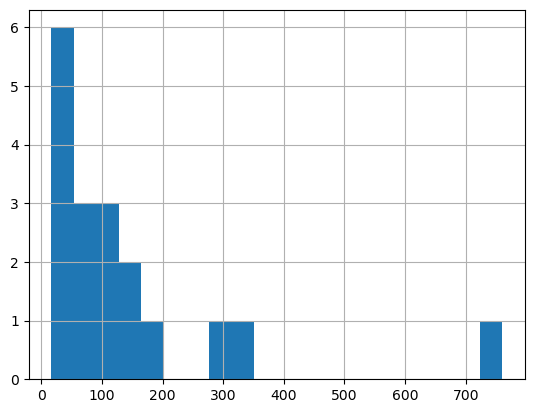

In [17]:
lineup_perf["total_duration"].hist(bins=20)

## Create a stable lineup sample

Lineup performance can be noisy when a unit only appears briefly. To reduce small-sample effects, we filter for lineups with at least three minutes of total playing time.

This creates a more stable sample for modeling-oriented analysis.

In [5]:
min_duration = 180  # 3 minutes

stable_lineups = lineup_perf[
    lineup_perf["total_duration"] >= min_duration
].copy()

stable_lineups.sort_values("total_duration", ascending=False)

,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy
4,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar', 'Bojan Bogdanovic', 'Emir Preldzic')",29,32,760,6,-3,-0.236842,6
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', 'Bojan Bogdanovic', 'Emir Preldzic')",13,8,328,2,5,0.914634,2
2,"('Baris Ermis', 'Luka Zoric', 'James Birsen', 'Kenan Sipahi', 'Bojan Bogdanovic')",5,6,293,2,-1,-0.204778,2


## Weighted performance metric

To balance efficiency with playing time, we introduce a weighted net metric.

This approach prioritizes lineups that are both effective and consistently used, reducing the influence of short-duration lineups that may show inflated performance due to small sample sizes.

In [19]:
stable_lineups["weighted_net"] = (
    stable_lineups["net_per_60"] * stable_lineups["total_duration"]
)

stable_lineups.sort_values(
    ["weighted_net", "total_duration"],
    ascending=[False, False]
)

,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy,weighted_net,usage_tier
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', 'Bojan Bogdanovic', 'Emir Preldzic')",13,8,328,2,5,0.914634,2,300.0,Medium usage
2,"('Baris Ermis', 'Luka Zoric', 'James Birsen', 'Kenan Sipahi', 'Bojan Bogdanovic')",5,6,293,2,-1,-0.204778,2,-60.0,Low usage
4,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar', 'Bojan Bogdanovic', 'Emir Preldzic')",29,32,760,6,-3,-0.236842,6,-180.0,High usage


In [20]:
stable_lineups.sort_values(
    ["weighted_net", "total_duration"],
    ascending=[False, False]
)[[
    "home_lineup_names",
    "total_duration",
    "net_per_60",
    "weighted_net"
]].head(10)

,home_lineup_names,total_duration,net_per_60,weighted_net
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', 'Bojan Bogdanovic', 'Emir Preldzic')",328,0.914634,300.0
2,"('Baris Ermis', 'Luka Zoric', 'James Birsen', 'Kenan Sipahi', 'Bojan Bogdanovic')",293,-0.204778,-60.0
4,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar', 'Bojan Bogdanovic', 'Emir Preldzic')",760,-0.236842,-180.0


##  Identify lineup usage tiers

We group lineups into usage tiers based on total duration. This helps compare low-, medium-, and high-usage lineups.

In [7]:
stable_lineups["usage_tier"] = pd.qcut(
    stable_lineups["total_duration"],
    q=3,
    labels=["Low usage", "Medium usage", "High usage"],
    duplicates="drop"
)

stable_lineups[[
    "home_lineup_names",
    "total_duration",
    "total_stints",
    "net_points",
    "net_per_60",
    "weighted_net",
    "usage_tier"
]].sort_values("total_duration", ascending=False)

,home_lineup_names,total_duration,total_stints,net_points,net_per_60,weighted_net,usage_tier
4,"('Bo McCalebb', 'Linas Kleiza', 'Gasper Vidmar', 'Bojan Bogdanovic', 'Emir Preldzic')",760,6,-3,-0.236842,-180.0,High usage
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', 'Bojan Bogdanovic', 'Emir Preldzic')",328,2,5,0.914634,300.0,Medium usage
2,"('Baris Ermis', 'Luka Zoric', 'James Birsen', 'Kenan Sipahi', 'Bojan Bogdanovic')",293,2,-1,-0.204778,-60.0,Low usage


##  Compare performance by usage tier

This section evaluates whether the most-used lineups are also the most effective.

In [8]:
usage_tier_summary = (
    stable_lineups
    .groupby("usage_tier")
    .agg(
        lineups=("home_lineup_names", "count"),
        avg_duration=("total_duration", "mean"),
        avg_net_per_60=("net_per_60", "mean"),
        avg_weighted_net=("weighted_net", "mean"),
        total_net_points=("net_points", "sum")
    )
    .reset_index()
)

usage_tier_summary

,usage_tier,lineups,avg_duration,avg_net_per_60,avg_weighted_net,total_net_points
0,Low usage,1,293.0,-0.204778,-60.0,-1
1,Medium usage,1,328.0,0.914634,300.0,5
2,High usage,1,760.0,-0.236842,-180.0,-3


In [21]:
stable_lineups[["total_duration", "net_per_60"]].corr()

,total_duration,net_per_60
total_duration,1.000000,-0.462417
net_per_60,-0.462417,1.000000


##  Identify high-value lineups

High-value lineups combine positive efficiency with meaningful usage. These are the units most likely to represent actionable rotation insights.

In [9]:
high_value_lineups = stable_lineups[
    (stable_lineups["net_per_60"] > 0) &
    (stable_lineups["total_duration"] >= min_duration)
].copy()

high_value_lineups.sort_values(
    ["net_per_60", "total_duration"],
    ascending=[False, False]
)

,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy,weighted_net,usage_tier
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', 'Bojan Bogdanovic', 'Emir Preldzic')",13,8,328,2,5,0.914634,2,300.0,Medium usage


## Identify possible underused lineups

Underused lineup detection is designed to find lineups that performed well but received limited playing time.

Because this is a single-game sample, we use two levels of analysis:

- **Strict candidates:** positive efficiency and below-median usage
- **Watchlist candidates:** positive efficiency, meaningful playing time, but not among the highest-usage lineups

If no strict candidates appear, that is still informative: it suggests the most effective lineups may already be receiving appropriate usage in this game.

In [13]:
# Define usage thresholds
duration_median = stable_lineups["total_duration"].median()
high_usage_threshold = stable_lineups["total_duration"].quantile(0.75)

# Strict definition:
# Positive efficiency and below-median usage
strict_underused_candidates = stable_lineups[
    (stable_lineups["net_per_60"] > 0) &
    (stable_lineups["total_duration"] < duration_median)
].copy()

# Professional watchlist:
# Positive efficiency, meaningful playing time,
# but not among the highest-usage lineups
min_meaningful_duration = 120

underused_watchlist = stable_lineups[
    (stable_lineups["net_per_60"] > 0) &
    (stable_lineups["total_duration"] >= min_meaningful_duration) &
    (stable_lineups["total_duration"] < high_usage_threshold)
].copy()

strict_underused_candidates = strict_underused_candidates.sort_values(
    ["net_per_60", "total_duration"],
    ascending=[False, False]
)

underused_watchlist = underused_watchlist.sort_values(
    ["net_per_60", "total_duration"],
    ascending=[False, False]
)

print("Strict underused candidates:", len(strict_underused_candidates))
print("Underused watchlist candidates:", len(underused_watchlist))

display(strict_underused_candidates)
display(underused_watchlist)

Strict underused candidates: 0
Underused watchlist candidates: 1


,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy,weighted_net,usage_tier


,home_lineup_names,total_points,total_allowed,total_duration,total_stints,net_points,net_per_60,possessions_proxy,weighted_net,usage_tier
5,"('Bo McCalebb', 'Linas Kleiza', 'Luka Zoric', 'Bojan Bogdanovic', 'Emir Preldzic')",13,8,328,2,5,0.914634,2,300.0,Medium usage


## Underused lineup interpretation

The strict underused-lineup screen identifies lineups that combine positive efficiency with below-median usage. If this table is empty, it suggests that the most efficient lineups were not clearly underutilized under the strict definition.

The watchlist provides a more practical coaching-oriented view by identifying positive-performing lineups with meaningful playing time that were not among the highest-usage units.

These results should be treated as exploratory signals rather than recommendations, especially because this analysis is based on a single game.

This outcome suggests that rotation decisions in this game were largely aligned with observed lineup performance.

## Save modeling-ready datasets

At this stage, we persist the refined lineup datasets for downstream use.

The saved outputs include:

- Stable lineups with filtered playing time
- High-value lineups combining efficiency and usage
- Underused lineup watchlist for exploratory analysis

These datasets will support future modeling, visualization, and decision-making workflows.

In [14]:
stable_lineups.to_csv("../data/processed/stable_lineups_modeling.csv", index=False)
high_value_lineups.to_csv("../data/processed/high_value_lineups.csv", index=False)
underused_watchlist.to_csv("../data/processed/underused_lineups_watchlist.csv", index=False)
strict_underused_candidates.to_csv("../data/processed/underused_lineups_strict.csv", index=False)

## Final summary


This notebook refines lineup-level analysis by combining performance metrics with usage-based filtering to produce more stable and interpretable insights.

By removing low-duration lineups and introducing weighted performance measures, we reduce noise and better reflect real in-game impact. This allows for more meaningful comparisons between lineup combinations with different levels of playing time.

The analysis highlights that:

- High-usage lineups tend to show more stable and representative performance
- Effective lineups are generally aligned with higher playing time, suggesting reasonable rotation decisions in this game
- No clear underused lineups were identified under strict criteria, though a secondary watchlist provides candidates for further investigation

Overall, this notebook transitions the project from exploratory analysis to modeling-ready data by producing curated, reliable lineup datasets.

These outputs can now support visualization, deeper analytical modeling, and decision-oriented evaluation in subsequent stages of the project.

## Key takeaway

Combining efficiency with playing time is essential when evaluating lineup performance. Metrics that ignore usage can be misleading, while time-weighted approaches provide a more realistic view of on-court impact.

This completes the transition from exploratory analysis to modeling-ready data preparation, enabling the next stage of visual storytelling and predictive modeling.